In [90]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt


In [91]:
aluminium_usgs_image_mapping ={
    'class_ 1': ['Canada'],
    'class_ 2': ['United States'],
    'class_ 3': ['Mexico'],
    'class_ 4': [],
    'class_ 5': ['Brazil'],
    'class_ 6': ['Argentina', 'Suriname', 'Venezuela'],
    'class_ 7': ['Egypt'],
    'class_ 8': ['Cameroon', 'Ghana', 'Nigeria'],
    'class_ 9': ['Mozambique'],
    'class_ 10': ['South Africa'],
    'class_ 11': [
        'Austria', 'France', 'Germany', 'Greece', 'Iceland',
        'Italy', 'Netherlands', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom'],
    'class_ 12': [
        'Bosnia and Herzegovina', 'Croatia', 'Czechoslovakia3', 'Hungary',
        'Montenegro', 'Poland', 'Romania', 'Serbia and Montenegro4', 'Slovakia',
        'Slovenia', 'Yugoslavia6'],
    'class_ 13': ['Turkey'],
    'class_ 14': ['Ukraine'],
    'class_ 15': ['Kazakhstan', 'Tajikistan'],
    'class_ 16': ['Russia', 'U.S.S.R.5'],
    'class_ 17': ['Azerbaijan', 'Bahrain', 'Iran', 'Oman', 'Qatar', 'Saudi Arabia', 'United Arab Emirates'],
    'class_ 18': ['India'],
    'class_ 19': ['Korea, Republic of'],
    'class_ 20': ['China'],
    'class_ 21': ['Malaysia'],
    'class_ 22': ['Indonesia'],
    'class_ 23': ['Japan'],
    'class_ 24': ['Australia', 'New Zealand'],
    'class_ 25': [],
    'class_ 26': [],
    'class_ 27': ['World']
    }

      

region_to_class = {
    'Argentina': 'class_ 6',  # Rest S.Am.
    'Albania' : 'class_ 12',  # C.Europe
    'Australia': 'class_ 24',  # Oceania
    'Austria': 'class_ 11',  # W.Europe
    'Azerbaijan': 'class_ 17',  # M.East (also arguable: Stan or Reforming)
    'Bahrain': 'class_ 17',  # M.East
    'Belgium': 'class_ 11',  # W.Europe
    'Bosnia and Herzegovina': 'class_ 12',  # C.Europe
    'Brazil': 'class_ 5',
    'Bulgaria': 'class_ 12',  # C.Europe
    'Burma' : 'class_ 21',  # SE.Asia (now Myanmar)
    'Cameroon': 'class_ 8',  # W.Africa
    'Canada': 'class_ 1',
    'China': 'class_ 20',
    'Chile': 'class_ 10',
    'Congo (Kinshasa)3': 'class_ 6',
    'Croatia': 'class_ 12',  # C.Europe
    'Czechoslovakia3': 'class_ 12',  # C.Europe (historical)
    'Czechoslovakia4': 'class_ 12',  # C.Europe (historical)
    'Czech Republic': 'class_ 12',  # C.Europe
    'Cyprus': 'class_ 12',  # C.Europe
    'Egypt': 'class_ 7',  # N.Africa
    'Finland': 'class_ 11',  # C.Europe
    'France': 'class_ 11',
    'Germany': 'class_ 11',
    'Ghana': 'class_ 8',  # W.Africa
    'Greece': 'class_ 11',
    'Hungary': 'class_ 12',
    'Iceland': 'class_ 11',
    'India': 'class_ 18',
    'Indonesia': 'class_ 22',
    'Iran': 'class_ 17',  # M.East
    'Italy': 'class_ 11',
    'Japan': 'class_ 23',
    'Kazakhstan': 'class_ 15',  # Stan
    'Korea, Republic of': 'class_ 19',
    'Laos': 'class_ 21',  # SE.Asia
    'Malaysia': 'class_ 21',  # SE.Asia
    'Mexico': 'class_ 3',
    'Mongolia' : 'class_ 20',  # China
    'Montenegro': 'class_ 12',
    'Mozambique': 'class_ 9',  # E.Africa
    'Netherlands': 'class_ 11',
    'New Zealand': 'class_ 24',
    'Nigeria': 'class_ 8',  # W.Africa
    'Norway': 'class_ 11',
    'Korea, North': 'class_ 19',
    'Oman': 'class_ 17',  # M.East
    'Peru': 'class_ 6',
    'Portugal': 'class_ 11',
    'Philippines': 'class_ 21',  # SE.Asia
    'Poland': 'class_ 12',
    'Qatar': 'class_ 17',
    'Romania': 'class_ 12',
    'Russia': 'class_ 16',
    'Saudi Arabia': 'class_ 17',
    'Serbia and Montenegro4': 'class_ 12',
    'Serbia and Montenegro5': 'class_ 12',
    'Serbia': 'class_ 12',
    'Slovakia': 'class_ 12',
    'Slovenia': 'class_ 12',
    'South Africa': 'class_ 10',
    'Spain': 'class_ 11',
    'Suriname': 'class_ 6',  # Rest S.Am.
    'Sweden': 'class_ 11',
    'Switzerland': 'class_ 11',
    'Taiwan': 'class_ 20',
    'Tajikistan': 'class_ 15',  # Stan
    'Thailand': 'class_ 21',  # SE.Asia
    'Turkey': 'class_ 13',
    'Ukraine': 'class_ 15',
    'U.S.S.R.5': 'class_ 16',
    'U.S.S.R.6': 'class_ 16',
    'Uzbekistan': 'class_ 15',
    'United Arab Emirates': 'class_ 17',
    'United Kingdom': 'class_ 11',
    'United States': 'class_ 2',
    'Venezuela': 'class_ 6',
    'Vietnam': 'class_ 21',
    'Yugoslavia6': 'class_ 12',
    'Yugoslavia7': 'class_ 12',
    'Zambia': 'class_ 10',
    'Zimbabwe': 'class_ 10',
    'World': 'class_ 27'
}


ISO_TO_CLASS = {
    'CAN': 'class_ 1',
    'USA': 'class_ 2',
    'MEX': 'class_ 3',
    'BLZ': 'class_ 4', 'GTM': 'class_ 4', 'NIC': 'class_ 4', 'PAN': 'class_ 4',
    'CUB': 'class_ 4', 'DOM': 'class_ 4', 'ANT': 'class_ 4', 'HTI': 'class_ 4',
    'JAM': 'class_ 4', 'TTO': 'class_ 4', 'ATG': 'class_ 4', 'KNA': 'class_ 4',
    'LCA': 'class_ 4', 'VCT': 'class_ 4', 'GRD': 'class_ 4', 'BHS': 'class_ 4',
    'BRB': 'class_ 4', 'DMA': 'class_ 4', 'CUW': 'class_ 4', 'CYM': 'class_ 4',
    'ARG': 'class_ 6', 'CHL': 'class_ 6', 'COL': 'class_ 6', 'ECU': 'class_ 6',
    'GUY': 'class_ 6', 'PER': 'class_ 6', 'PRY': 'class_ 6', 'SUR': 'class_ 6',
    'URY': 'class_ 6', 'VEN': 'class_ 6', 'BOL': 'class_ 6', 'GUF': 'class_ 6',
    'DZA': 'class_ 7', 'EGY': 'class_ 7', 'MAR': 'class_ 7', 'TUN': 'class_ 7',
    'LBY': 'class_ 7',
    'CMR': 'class_ 8', 'CIV': 'class_ 8', 'GHA': 'class_ 8', 'GIN': 'class_ 8',
    'GMB': 'class_ 8', 'SEN': 'class_ 8', 'TGO': 'class_ 8', 'BEN': 'class_ 8',
    'MLI': 'class_ 8', 'NGA': 'class_ 8', 'BFA': 'class_ 8', 'NER': 'class_ 8',
    'ETH': 'class_ 9', 'KEN': 'class_ 9', 'UGA': 'class_ 9', 'RWA': 'class_ 9',
    'BDI': 'class_ 9', 'TZA': 'class_ 9', 'DJI': 'class_ 9', 'SOM': 'class_ 9',
    'ERI': 'class_ 9', 'SSD': 'class_ 9',
    'ZAF': 'class_ 10', 'SWZ': 'class_ 10', 'LSO': 'class_ 10',
    'NAM': 'class_ 10', 'BWA': 'class_ 10',
    'AUT': 'class_ 11', 'BEL': 'class_ 11', 'DEU': 'class_ 11',
    'DNK': 'class_ 11', 'ESP': 'class_ 11', 'FIN': 'class_ 11',
    'FRA': 'class_ 11', 'GBR': 'class_ 11', 'GRC': 'class_ 11',
    'IRL': 'class_ 11', 'ISL': 'class_ 11', 'ITA': 'class_ 11',
    'LUX': 'class_ 11', 'NLD': 'class_ 11', 'NOR': 'class_ 11',
    'PRT': 'class_ 11', 'SWE': 'class_ 11', 'CHE': 'class_ 11',
    'ALB': 'class_ 12', 'BGR': 'class_ 12', 'BIH': 'class_ 12',
    'CZE': 'class_ 12', 'HRV': 'class_ 12', 'HUN': 'class_ 12',
    'MDA': 'class_ 12', 'MKD': 'class_ 12', 'MNE': 'class_ 12',
    'POL': 'class_ 12', 'ROU': 'class_ 12', 'SCG': 'class_ 12',
    'SRB': 'class_ 12', 'SVK': 'class_ 12', 'SVN': 'class_ 12',
    'TUR': 'class_ 13',
    'UKR': 'class_ 14', 'BLR': 'class_ 14',
    'KAZ': 'class_ 15', 'KGZ': 'class_ 15', 'TJK': 'class_ 15',
    'TKM': 'class_ 15', 'UZB': 'class_ 15',
    'RUS': 'class_ 16',
    'BHR': 'class_ 17', 'IRN': 'class_ 17', 'IRQ': 'class_ 17',
    'ISR': 'class_ 17', 'JOR': 'class_ 17', 'KWT': 'class_ 17',
    'LBN': 'class_ 17', 'OMN': 'class_ 17', 'PSE': 'class_ 17',
    'QAT': 'class_ 17', 'SAU': 'class_ 17', 'SYR': 'class_ 17',
    'ARE': 'class_ 17', 'YEM': 'class_ 17',
    'IND': 'class_ 18',
    'KOR': 'class_ 19',
    'CHN': 'class_ 20', 'HKG': 'class_ 20', 'MAC': 'class_ 20',
    'MYS': 'class_ 21', 'SGP': 'class_ 21', 'THA': 'class_ 21',
    'VNM': 'class_ 21', 'PHL': 'class_ 21', 'MMR': 'class_ 21',
    'KHM': 'class_ 21', 'LAO': 'class_ 21',
    'IDN': 'class_ 22',
    'JPN': 'class_ 23',
    'AUS': 'class_ 24', 'NZL': 'class_ 24', 'FJI': 'class_ 24',
    'VUT': 'class_ 24', 'TON': 'class_ 24', 'WSM': 'class_ 24',
    'PNG': 'class_ 24', 'SLB': 'class_ 24', 'WLF': 'class_ 24',
    'TUV': 'class_ 24', 'NRU': 'class_ 24', 'KIR': 'class_ 24',
    'COK': 'class_ 24', 'PYF': 'class_ 24', 'NCL': 'class_ 24',
    'LKA': 'class_ 25', 'BGD': 'class_ 25', 'NPL': 'class_ 25',
    'MDV': 'class_ 25', 'BTN': 'class_ 25', 'AFG': 'class_ 25',
    'PAK': 'class_ 25',
    'MOZ': 'class_ 26', 'ZMB': 'class_ 26', 'ZWE': 'class_ 26',
    'AGO': 'class_ 26', 'COD': 'class_ 26', 'CAF': 'class_ 26',
    'GAB': 'class_ 26', 'COG': 'class_ 26', 'STP': 'class_ 26',
    'SLE': 'class_ 26', 'GNQ': 'class_ 26', 'TCD': 'class_ 26',
    'MWI': 'class_ 26',
    # 'class_ 27' is for Global — not mapped to ISO
}




In [92]:
# read in Aluminium trade data from UN comtrade database (https://comtradeplus.un.org/)
# trade data available from 1988 on
# use Imports and Exports for – HS 7601 (Unwrought aluminium), 7602 (Aluminium waste and scrap) for all regions
# for now exclude  7603–7616 (final products to avoid double counting) - could be worth to check later
# read in in 4 steps, as database does not allow selection of more years at once
# unit: kg

copper_1988_1998 = pd.read_csv('copper_trade_1988_1998_qty.csv', 
                   encoding="iso-8859-1", index_col=False)

copper_1999_2010 = pd.read_csv('copper_trade_1999_2010_qty.csv', 
                     encoding="iso-8859-1", index_col=False)

copper_2011_2022 = pd.read_csv('copper_trade_2011_2022_qty.csv', 
                   encoding="iso-8859-1", index_col=False)


copper_trade = pd.concat([copper_1988_1998, copper_1999_2010, copper_2011_2022])

# copper app cons

copper_app_cons = pd.read_csv('copper.csv', index_col=0)

# read in global production data from USGS (United States Geological Survey) https://www.usgs.gov/centers/national-minerals-information-center/historical-global-statistics-mineral-and-material
# Aluminum Copper ds896-copper.xlsx  1990-2011
# unit: metric tons
copper_production_usgs = pd.read_excel('copper_refined_usgs.xlsx', index_col=0, header = 0)
copper_production_usgs = copper_production_usgs.T




In [93]:
# Continue with USGS data beacuse more regions available and data is 100% similar to AIA data

# map USGS regions to IMAGE regions
copper_production_usgs_image = copper_production_usgs.rename(columns=region_to_class)
# Class 4, 25, and 26 are empty - fill with nan
copper_production_usgs_image.loc[:, 'class_ 4'] = np.nan   # Central America
copper_production_usgs_image.loc[:, 'class_ 8'] = np.nan  # West Africa
copper_production_usgs_image.loc[:, 'class_ 9'] = np.nan  # East Africa
copper_production_usgs_image.loc[:, 'class_ 14'] = np.nan  # Southern Africa
copper_production_usgs_image.loc[:, 'class_ 25'] = np.nan  
copper_production_usgs_image.loc[:, 'class_ 26'] = np.nan  

copper_production_usgs_image = copper_production_usgs_image.replace('--', np.nan)
copper_production_usgs_image = copper_production_usgs_image.replace('XX', np.nan)

# Aggregate by IAMGE classes
copper_production_usgs_image = copper_production_usgs_image.T.groupby(level=0).sum().T

# make sure all index is int
copper_production_usgs_image.index = copper_production_usgs_image.index.astype(int)

C:\Users\Arp00003\AppData\Local\Temp\ipykernel_10792\1693151160.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  copper_production_usgs_image = copper_production_usgs_image.replace('--', np.nan)
C:\Users\Arp00003\AppData\Local\Temp\ipykernel_10792\1693151160.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  copper_production_usgs_image = copper_production_usgs_image.replace('XX', np.nan)


In [94]:
copper_production_usgs_image.columns.name = "region"
copper_production_usgs_image.index.name = "year"

In [105]:
# Manipulate trade data to also match the IMAGE data strucutre.
# also pivot the trade data to have imports and exports in separate columns
# calculate net trade as imports - exports

# Pivot: sum imports (M) and exports (X) by year and region
trade_pivot = copper_trade.pivot_table(
    index=['refYear', 'reporterISO'],
    columns='flowCode',
    values='qty',
    aggfunc='sum',
    fill_value=0  # Replace NaNs with 0 if there's only import or export
).reset_index()

# Calculate net trade: imports - exports
trade_pivot['netTrade_kg'] = trade_pivot.get('M', 0) - trade_pivot.get('X', 0)

# Map ISO to class
trade_pivot['region'] = trade_pivot['reporterISO'].map(ISO_TO_CLASS)

# Group by class and sum the relevant columns
trade_image = trade_pivot.groupby(['refYear','region'])[['M', 'X', 'netTrade_kg']].sum().reset_index()

# Pivot again to get class as columns, year as index and net trade as values
trade_image_pivot = trade_image.pivot(index='refYear', columns='region', values='netTrade_kg')

trade_image_pivot.index.name = "year"
trade_image_pivot.columns.name = "region"

# to tons
trade_image_pivot = trade_image_pivot / 1000

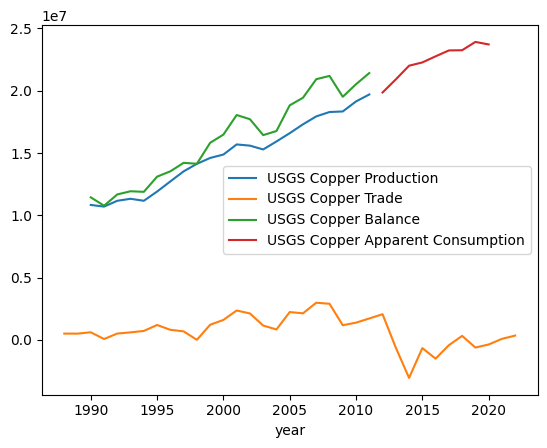

In [109]:
copper_production_usgs_image.sum(axis = 1).plot(label='USGS Copper Production')
trade_image_pivot.sum(axis=1).plot(label='USGS Copper Trade')
diff = copper_production_usgs_image.sum(axis = 1) + trade_image_pivot.sum(axis=1)
diff.plot(label='USGS Copper Balance')

copper_app_cons.sum(axis=1).plot(label='USGS Copper Apparent Consumption')

plt.legend()


In [116]:
diff_all_regions = copper_production_usgs_image + trade_image_pivot

def natural_class_sort(col):
    # Extract the number after 'class_ ' for sorting
    try:
        return int(col.split('_')[1])
    except (IndexError, ValueError):
        return float('inf')  # put non-matching columns at the end

diff_all_regions = diff_all_regions.reindex(
    sorted(diff_all_regions.columns, key=natural_class_sort), axis=1
)



In [120]:
diff_all_regions.index

Index([1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
      dtype='int64', name='year')

In [118]:
diff_all_regions.to_csv('copper_new.csv')